In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Data Splitting

In this section we'll split the `DB_final.csv` to 3 groups (Google, Gemini, and Marian) Then we will translate each group using the corresponding model and save them to separate files for further evaluation.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data/DB_final.csv')

le = LabelEncoder()                                        
y_encoded = le.fit_transform(df['Writer'])

_,test_data,_, _= train_test_split(
    df, 
    y_encoded, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_encoded   # same class distribution in train and test
)


In [ ]:
test_data["Writer"].value_counts()

model_builder
GPT_4-o                              1465
accounts/yi-01-ai/models/yi-large    1464
qwen-2-72B                           1463
mistral-7B                           1463
gemma-2-9b                           1462
llama-8B                             1461
Human_story                          1459
Name: count, dtype: int64

In [7]:
TEXT_LEN=test_data['Text'].apply(len)

In [8]:
print("Sum :", TEXT_LEN.sum())
print("Desc :\n",TEXT_LEN.describe())

Sum : 31758954
Desc :
 count     10237.000000
mean       3102.369249
std        3850.567207
min          21.000000
25%        2241.000000
50%        2704.000000
75%        3385.000000
max      177410.000000
Name: Text, dtype: float64


In [9]:
def IQR(lst):
    q1 = lst.quantile(0.25)
    q3 = lst.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

print("IQR bounds:", IQR(TEXT_LEN))
print("number of high outliers:", sum(TEXT_LEN > IQR(TEXT_LEN)[1]))
print("number of low outliers:", sum(TEXT_LEN < IQR(TEXT_LEN)[0]))

IQR bounds: (np.float64(525.0), np.float64(5101.0))
number of high outliers: 377
number of low outliers: 357


In [ ]:
lower_bound, upper_bound = IQR(TEXT_LEN)
clean_test_df = test_data[(TEXT_LEN >= lower_bound) & (TEXT_LEN <= upper_bound)].copy()

# Split the cleaned test data into three equal parts for Google, Gemini, and Nllb
df_google, temp_df = train_test_split(clean_test_df, test_size=0.66, random_state=999,stratify=clean_test_df['Writer'])
df_gemini, df_Nllb = train_test_split(temp_df, test_size=0.5, random_state=42,stratify=temp_df['Writer'])

df_google.to_csv('data/paraphrasing/google_test_data.csv', index=False)
df_gemini.to_csv('data/paraphrasing/gemini_test_data.csv', index=False)
df_Nllb.to_csv('data/paraphrasing/Nllb_test_data.csv', index=False)

In [ ]:
df_Nllb_TEXT_LEN=df_Nllb['Text'].apply(len)
print("Nllb Sum :", df_Nllb_TEXT_LEN.sum())
print("Nllb Desc :\n",df_Nllb_TEXT_LEN.describe())

Marian Sum : 8877576
Marian Desc :
 count    3136.000000
mean     2830.859694
std       768.759921
min       526.000000
25%      2274.000000
50%      2705.000000
75%      3315.000000
max      5060.000000
Name: Text, dtype: float64


# Nllb

In [ ]:
import os
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline, BitsAndBytesConfig


# VRAM optimization
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
input_file = 'data/paraphrasing/nllb_test_data.csv'
output_file = "data/paraphrasing/nllb/DB_test_paraphrased_1.3B_ULTRA.csv"
os.makedirs(os.path.dirname(output_file), exist_ok=True)

def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-1.3B", quantization_config=bnb_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-1.3B")

# 16 bit batch processing pipeline
translator = pipeline(
    "translation", 
    model=model, 
    tokenizer=tokenizer, 
    batch_size=16  
)

def process_ultra(df):
    if os.path.exists(output_file):
        processed_df = pd.read_csv(output_file)
        start_idx = len(processed_df)
        print(f"Resuming from index: {start_idx}")
    else:
        processed_df = pd.DataFrame()
        start_idx = 0

    remaining_df = df.iloc[start_idx:].copy()
    if remaining_df.empty: return processed_df

    all_chunks = [] # Text chunks for batch processing
    chunk_map = []  #Original indices mapping

    print("Fragmenting texts into chunks...")
    for idx, row in remaining_df.iterrows():
        words = str(row['Text']).split()
        parts = [' '.join(words[i:i + 250]) for i in range(0, len(words), 250)]
        all_chunks.extend(parts)
        chunk_map.extend([idx] * len(parts))

    print(f"Processing {len(all_chunks)} fragments on GPU...")
    
    # ENG -> FRA
    fr_results = []
    for out in tqdm(translator(all_chunks, src_lang="eng_Latn", tgt_lang="fra_Latn", max_length=512, truncation=True), 
                    total=len(all_chunks), desc="Step 1/2: ENG -> FRA"):
        fr_results.append(out['translation_text'])
    
    clear_vram()

    # FRA -> ENG
    en_results = []
    for out in tqdm(translator(fr_results, src_lang="fra_Latn", tgt_lang="eng_Latn", max_length=512, truncation=True), 
                    total=len(fr_results), desc="Step 2/2: FRA -> ENG"):
        en_results.append(out['translation_text'])

    print("Reassembling fragments...")
    paraphrased_dict = {}
    for i, original_idx in enumerate(chunk_map):
        if original_idx not in paraphrased_dict:
            paraphrased_dict[original_idx] = []
        paraphrased_dict[original_idx].append(en_results[i])

    final_texts = []
    for idx in remaining_df.index:
        final_texts.append(' '.join(paraphrased_dict[idx]))

    remaining_df['paraphrased_text'] = final_texts
    remaining_df['engine'] = 'NLLB-1.3B-UltraBatch'

    final_df = pd.concat([processed_df, remaining_df], ignore_index=True)
    final_df.to_csv(output_file, index=False)
    print(f"Mission Accomplished! Saved to {output_file}")

if __name__ == "__main__":
    df_input = pd.read_csv(input_file)
    process_ultra(df_input)

Device set to use cuda:0


Fragmenting texts into chunks...
Processing 7101 fragments on GPU...


Your input_length: 489 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 468 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 488 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 461 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 465 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 475 is bigger than 0.9 * max_length: 512. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 497 is bigger than 0.9 * max_length: 512. You

Reassembling fragments...
Mission Accomplished! Saved to data/paraphrasing/nllb/DB_test_paraphrased_1.3B_ULTRA.csv


## Testing

test the semantic similarity function using `all-MiniLM-L6-v2` model

In [4]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch

df = pd.read_csv("data/paraphrasing/nllb/DB_test_paraphrased_1.3B_ULTRA.csv")

model = SentenceTransformer('all-MiniLM-L6-v2')

def calculate_semantic_similarity(original_list, paraphrased_list):
    embeddings1 = model.encode(original_list, convert_to_tensor=True)
    embeddings2 = model.encode(paraphrased_list, convert_to_tensor=True)
    
    cosine_scores = util.cos_sim(embeddings1, embeddings2)
    return torch.diagonal(cosine_scores).tolist()

print("Calculating semantic similarity...")
df['semantic_similarity'] = calculate_semantic_similarity(df['Text'].tolist(), df['paraphrased_text'].tolist())

print(df['semantic_similarity'].describe())


Calculating semantic similarity...
count    3136.000000
mean        0.841892
std         0.093908
min         0.052721
25%         0.803616
50%         0.862225
75%         0.905277
max         0.992018
Name: semantic_similarity, dtype: float64


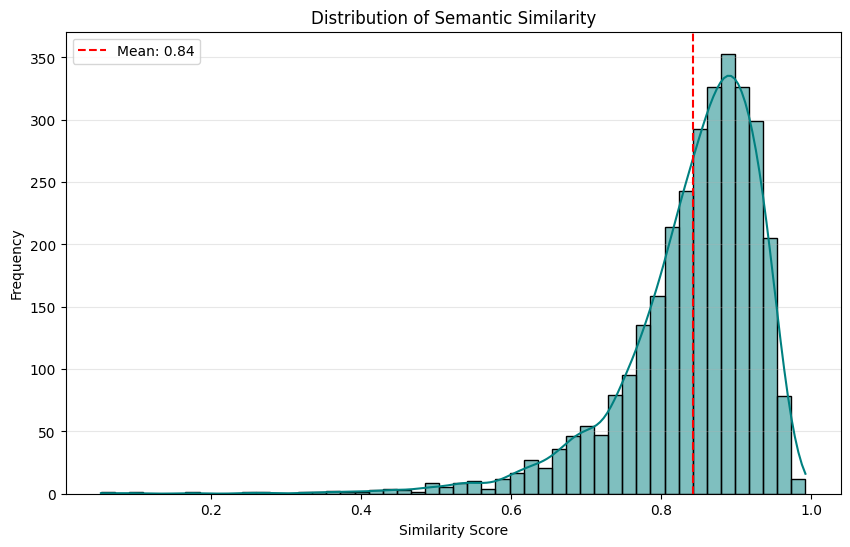

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['semantic_similarity'], bins=50, kde=True, color='teal')

plt.title('Distribution of Semantic Similarity')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.axvline(df['semantic_similarity'].mean(), color='red', linestyle='--', label=f'Mean: {df["semantic_similarity"].mean():.2f}')
plt.legend()

plt.show()

In [12]:
# Drop low semantic similarity samples
df_cleaned = df[df['semantic_similarity'] >= 0.60].copy()
print(f"Cleaned! Kept {len(df_cleaned)} high-quality paraphrased samples.")
df_cleaned.to_csv("data/paraphrasing/nllb/with_semantic_similarity.csv", index=False)

Cleaned! Kept 3064 high-quality paraphrased samples.


# Gemini

In [19]:
df=pd.read_csv("data/paraphrasing/gemini_test_data.csv")

In [20]:
df.shape

(3136, 19)

In [28]:
import os
GEMINI_API_KEY = os.environ.get('API_KEY')

In [31]:
GEMINI_API_KEY

None
